# Discriminant Analysis: Classifying Product Preferences from Customer Attributes

This Notebook applies Linear Discriminant Analysis (LDA) to classify a customer's preferred product category using customer attributes and purchasing behavior.

# 判別分析：顧客属性から商品カテゴリを分類する

このNotebookでは、顧客属性と購買行動を使い、顧客が選好する商品カテゴリを線形判別分析（LDA）で分類します。

## 1. Learning Objectives / 学習目標

- Understand the purpose of discriminant analysis
- Compare cluster analysis and discriminant analysis
- Build and evaluate a multiclass LDA model
- Interpret confusion matrices and classification reports
- Visualize customers in discriminant space
- Predict categories for new customers

- 判別分析の目的を理解する
- クラスター分析との違いを理解する
- 多クラスLDAモデルを構築・評価する
- 混同行列と分類レポートを読む
- 判別空間を可視化する
- 新規顧客のカテゴリを予測する

## 2. Use Case / ユースケース

An e-commerce company wants to recommend a suitable product category to each customer using historical labeled data.

あるECサイトでは、過去の正解ラベル付きデータから、顧客ごとに適した商品カテゴリを推薦したいと考えています。

## 3. Cluster Analysis and Discriminant Analysis / クラスター分析との違い

| Cluster Analysis | Discriminant Analysis |
|---|---|
| Unsupervised learning | Supervised learning |
| No target label | Known target label |
| Discovers unknown groups | Predicts membership in known groups |
| 教師なし学習 | 教師あり学習 |
| 目的変数なし | 目的変数あり |
| 未知のグループを発見する | 既知のグループへの所属を予測する |

## 4. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## 5. Load the Dataset / データの読み込み

In [2]:
candidate_paths = [
    Path("../data/customer_product_preference.csv"),
    Path("05_discriminant_analysis/data/customer_product_preference.csv"),
    Path("data/customer_product_preference.csv"),
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("customer_product_preference.csv was not found.")
df = pd.read_csv(data_path)
df.head()

,customer_id,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase,preferred_category
0,D001,34,64000,5.9,199.49,62.4,14.2,25,Electronics
1,D002,37,72300,2.3,122.98,66.9,37.5,32,Electronics
2,D003,43,67800,2.8,126.01,37.8,44.1,43,Home_Living
3,D004,20,49200,5.6,62.90,48.8,82.4,25,Fashion
4,D005,40,64300,2.3,106.55,65.2,15.6,32,Home_Living


## 6. Understand the Dataset / データの理解

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 180
Columns: 9
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               180 non-null    str    
 1   age                       180 non-null    int64  
 2   annual_income             180 non-null    int64  
 3   purchase_frequency        180 non-null    float64
 4   average_order_value       180 non-null    float64
 5   online_purchase_ratio     180 non-null    float64
 6   discount_usage_rate       180 non-null    float64
 7   days_since_last_purchase  180 non-null    int64  
 8   preferred_category        180 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 12.8 KB


In [4]:
df.isna().sum()

customer_id                 0
age                         0
annual_income               0
purchase_frequency          0
average_order_value         0
online_purchase_ratio       0
discount_usage_rate         0
days_since_last_purchase    0
preferred_category          0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,180.0,36.383333,10.120103,18.00,27.0000,36.000,43.0000,62.00
annual_income,180.0,68381.111111,17883.486309,29000.00,54800.0000,66400.000,80425.0000,111100.00
purchase_frequency,180.0,6.708889,2.708136,0.50,5.0750,6.500,8.6000,13.50
average_order_value,180.0,119.752889,40.528019,23.54,86.4675,120.115,152.3375,219.09
online_purchase_ratio,180.0,65.523889,22.705293,5.00,51.8250,69.600,83.1750,100.00
discount_usage_rate,180.0,43.692778,21.024854,5.80,28.5000,42.150,55.2750,100.00
days_since_last_purchase,180.0,21.627778,14.273478,1.00,11.0000,19.000,29.0000,64.00


In [6]:
category_counts = df['preferred_category'].value_counts().sort_index()
category_counts

preferred_category
Electronics    60
Fashion        60
Home_Living    60
Name: count, dtype: int64

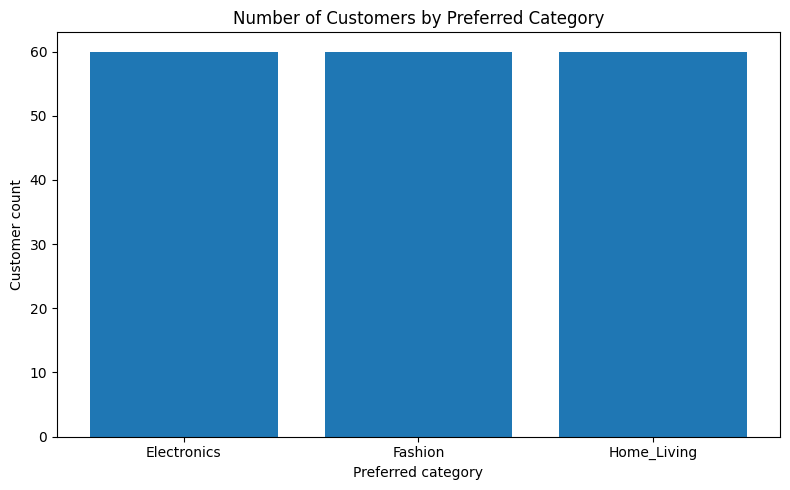

In [7]:
plt.figure(figsize=(8,5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Number of Customers by Preferred Category")
plt.xlabel("Preferred category")
plt.ylabel("Customer count")
plt.tight_layout()
plt.show()

## 7. Explore Differences between Categories / カテゴリごとの特徴

In [8]:
features = [
    "age",
    "annual_income",
    "purchase_frequency",
    "average_order_value",
    "online_purchase_ratio",
    "discount_usage_rate",
    "days_since_last_purchase",
]
category_profile = df.groupby("preferred_category")[features].mean().round(2)
category_profile

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
preferred_category,,,,,,,
Electronics,35.33,75941.67,6.97,143.14,80.36,31.40,19.02
Fashion,28.60,59720.00,8.59,82.47,72.19,58.95,15.73
Home_Living,45.22,69481.67,4.57,133.65,44.02,40.73,30.13


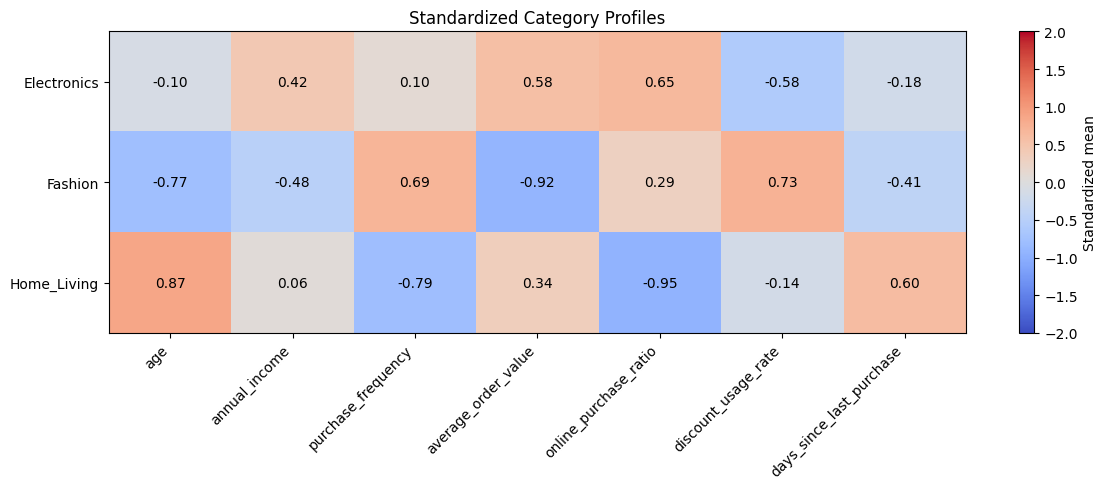

In [9]:
standardized_profile = (category_profile - df[features].mean()) / df[features].std()

fig, ax = plt.subplots(figsize=(12,5))
image = ax.imshow(standardized_profile.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(range(len(features)), labels=features, rotation=45, ha="right")
ax.set_yticks(range(len(standardized_profile.index)), labels=standardized_profile.index)

for i in range(standardized_profile.shape[0]):
    for j in range(standardized_profile.shape[1]):
        ax.text(j, i, f"{standardized_profile.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Standardized mean")
ax.set_title("Standardized Category Profiles")
plt.tight_layout()
plt.show()

## 8. Prepare Explanatory and Target Variables / 説明変数と目的変数

In [10]:
X = df[features].copy()
y = df["preferred_category"].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 7)
y shape: (180,)


## 9. Split Training and Test Data / 学習・テストデータへの分割

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (135, 7)
Test: (45, 7)


## 10. Build the LDA Model / 線形判別分析モデル

A pipeline standardizes variables and then fits Linear Discriminant Analysis.

パイプラインで標準化を行った後、線形判別分析を学習します。

In [12]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis()),
])
model.fit(X_train, y_train)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lda', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot

## 11. Predict the Test Data / テストデータの予測

In [13]:
y_pred = model.predict(X_test)
result = X_test.copy()
result["actual"] = y_test
result["predicted"] = y_pred
result.head(10)

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase,actual,predicted
12,26,73900,8.2,68.08,97.7,62.8,18,Fashion,Fashion
102,46,94500,6.1,219.09,26.3,51.6,32,Home_Living,Home_Living
33,49,89700,3.7,130.58,18.3,87.4,23,Home_Living,Home_Living
125,24,39800,5.1,179.81,70.5,30.2,17,Electronics,Electronics
64,42,98300,6.2,124.06,64.5,34.7,43,Electronics,Home_Living
69,48,53600,6.6,156.72,45.0,40.6,10,Home_Living,Home_Living
144,59,90400,5.4,158.73,27.2,44.3,60,Home_Living,Home_Living
19,25,66100,5.9,110.81,90.7,37.7,38,Electronics,Electronics
87,51,44600,3.4,135.09,22.7,37.7,29,Home_Living,Home_Living
112,47,69500,5.3,121.13,33.4,21.3,28,Home_Living,Home_Living


## 12. Evaluate Classification Performance / 分類性能の評価

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.889


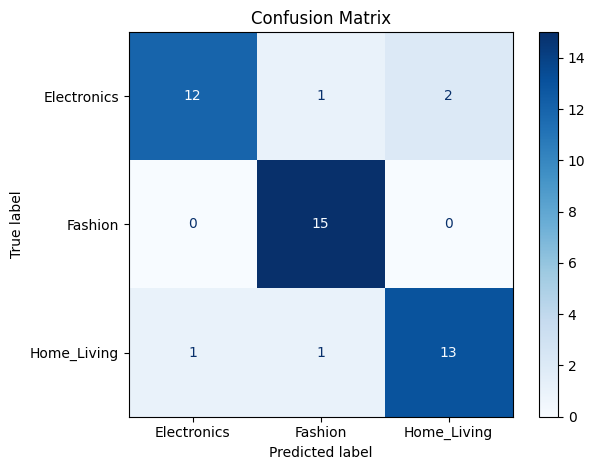

In [15]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

In [16]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

 Electronics      0.923     0.800     0.857        15
     Fashion      0.882     1.000     0.938        15
 Home_Living      0.867     0.867     0.867        15

    accuracy                          0.889        45
   macro avg      0.891     0.889     0.887        45
weighted avg      0.891     0.889     0.887        45



### How to Read the Metrics / 評価指標の読み方

- **Precision**: Of the customers predicted as a category, how many actually belong to it?
- **Recall**: Of the customers who actually belong to a category, how many were correctly identified?
- **F1-score**: A balance between precision and recall.

- **適合率**：そのカテゴリと予測した顧客のうち、実際にそのカテゴリだった割合。
- **再現率**：実際にそのカテゴリである顧客のうち、正しく見つけられた割合。
- **F1スコア**：適合率と再現率のバランスを表す指標。

## 13. Cross-Validation / 交差検証

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("Scores:", np.round(scores, 3))
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

Scores: [0.861 0.917 0.861 0.917 0.833]
Mean accuracy: 0.878
Standard deviation: 0.033


## 14. Visualize the Discriminant Space / 判別空間の可視化

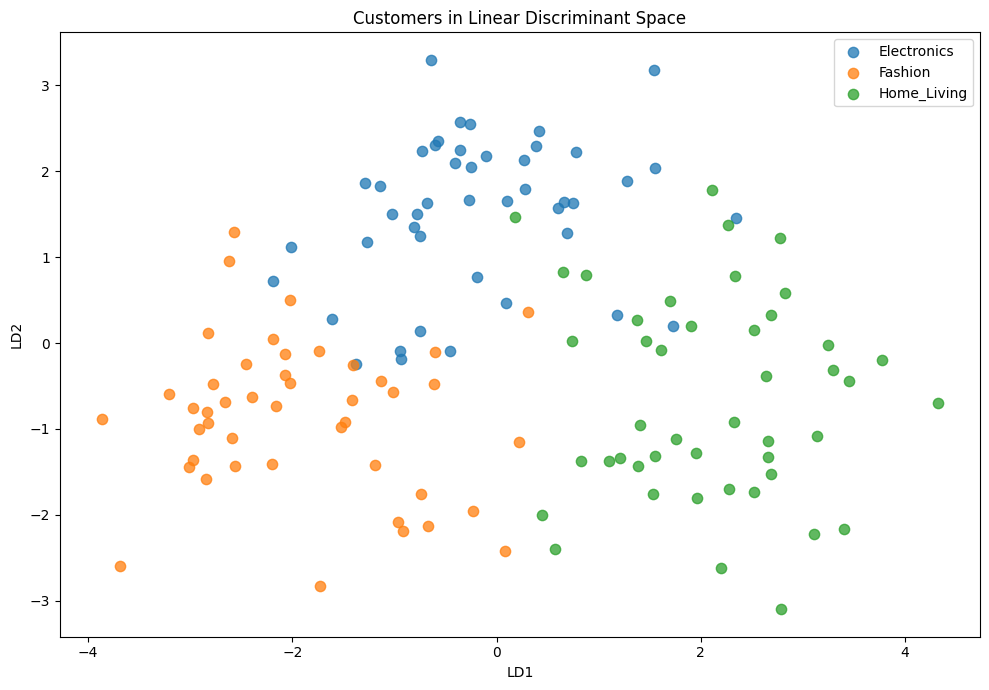

In [18]:
scaler = model.named_steps["scaler"]
lda = model.named_steps["lda"]
X_train_lda = lda.transform(scaler.transform(X_train))

lda_df = pd.DataFrame({
    "LD1": X_train_lda[:,0],
    "LD2": X_train_lda[:,1],
    "preferred_category": y_train.to_numpy(),
})

plt.figure(figsize=(10,7))
for category in sorted(lda_df["preferred_category"].unique()):
    subset = lda_df[lda_df["preferred_category"] == category]
    plt.scatter(subset["LD1"], subset["LD2"], label=category, s=55, alpha=0.75)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Customers in Linear Discriminant Space")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Examine Discriminant Coefficients / 判別係数

In [19]:
coef_df = pd.DataFrame(lda.coef_, index=lda.classes_, columns=features).round(3)
coef_df

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
Electronics,-0.336,0.545,-0.008,1.030,1.342,-0.733,-0.337
Fashion,-1.267,-0.586,0.862,-1.681,0.533,0.842,-0.751
Home_Living,1.602,0.041,-0.854,0.651,-1.875,-0.109,1.088


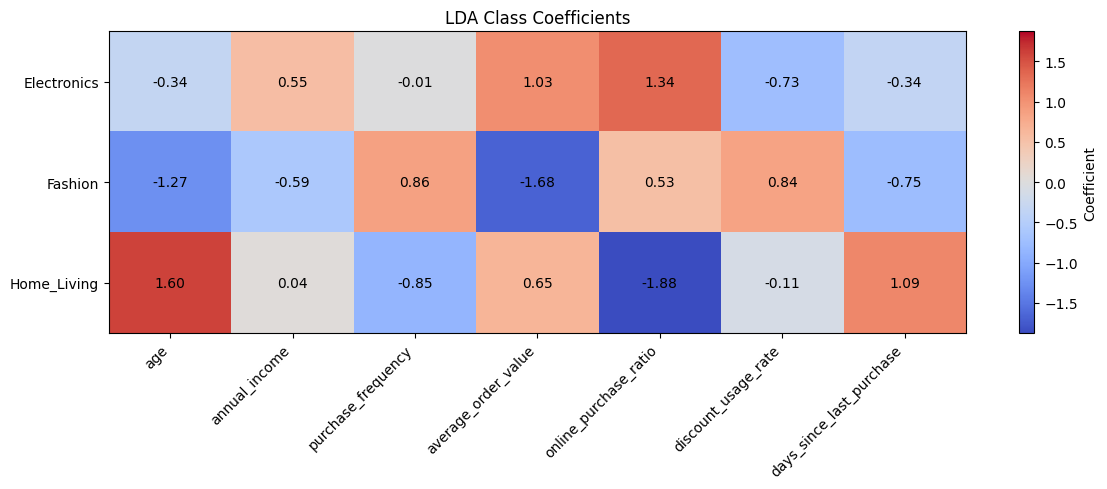

In [20]:
fig, ax = plt.subplots(figsize=(12,5))
limit = np.abs(coef_df.values).max()
image = ax.imshow(coef_df.values, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
ax.set_xticks(range(len(features)), labels=features, rotation=45, ha="right")
ax.set_yticks(range(len(coef_df.index)), labels=coef_df.index)

for i in range(coef_df.shape[0]):
    for j in range(coef_df.shape[1]):
        ax.text(j, i, f"{coef_df.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Coefficient")
ax.set_title("LDA Class Coefficients")
plt.tight_layout()
plt.show()

## 16. Predict New Customers / 新しい顧客の判別

In [21]:
new_customers = pd.DataFrame([
    {"age":31,"annual_income":82000,"purchase_frequency":7.5,"average_order_value":158.0,
     "online_purchase_ratio":91.0,"discount_usage_rate":24.0,"days_since_last_purchase":9},
    {"age":27,"annual_income":51000,"purchase_frequency":10.2,"average_order_value":74.0,
     "online_purchase_ratio":82.0,"discount_usage_rate":76.0,"days_since_last_purchase":12},
    {"age":53,"annual_income":70000,"purchase_frequency":4.0,"average_order_value":132.0,
     "online_purchase_ratio":35.0,"discount_usage_rate":38.0,"days_since_last_purchase":41},
])

predictions = model.predict(new_customers)
probabilities = model.predict_proba(new_customers)

output = new_customers.copy()
output["predicted_category"] = predictions
probability_df = pd.DataFrame(
    probabilities,
    columns=[f"prob_{category}" for category in lda.classes_],
)
pd.concat([output, probability_df], axis=1).round(3)

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase,predicted_category,prob_Electronics,prob_Fashion,prob_Home_Living
0,31,82000,7.5,158.0,91.0,24.0,9,Electronics,0.997,0.003,0.0
1,27,51000,10.2,74.0,82.0,76.0,12,Fashion,0.001,0.999,0.0
2,53,70000,4.0,132.0,35.0,38.0,41,Home_Living,0.000,0.000,1.0


## 17. Assumptions and Limitations / 前提条件と限界

- Approximate multivariate normality within classes
- Similar covariance matrices across classes
- Linear separation
- Independent observations
- Sensitivity to label quality and changing preferences
- Simulated educational data

- 各カテゴリ内でのおおむね多変量正規性
- カテゴリ間で近い共分散行列
- 線形な分離関係
- 観測値の独立性
- ラベル品質や選好変化への依存
- 学習用シミュレーションデータ

## 18. Conclusion / まとめ

This Notebook used Linear Discriminant Analysis to classify customer product preferences and evaluated the model with a test set and cross-validation.

このNotebookでは、線形判別分析で顧客の商品カテゴリ選好を分類し、テストデータと交差検証で性能を評価しました。